In [2]:
def calculate_training_flops(
    n_blocks: int,
    model_dim: int,
    batch_size: int,
    seq_len: int,
    vocab_size: int,
    attention_type: str = "regular",
    top_k: int = 32,
) -> float:
    """
    Calculates the approximate total training FLOPs for a Transformer model.

    Args:
        n_blocks: Number of transformer layers
        model_dim: Hidden dimension size (D)
        batch_size: Number of sequences per batch (B)
        seq_len: Number of tokens per sequence (S)
        vocab_size: Size of the vocabulary (V)
        attention_type: 'regular' for standard attention, 'pk' for Product Keys
        top_k: The K value used if attention_type is 'pk'

    Returns:
        Total floating point operations required for training.
    """
    # Aliases for mathematical readability
    B = batch_size
    S = seq_len
    D = model_dim
    V = vocab_size
    K = top_k

    # ---------------------------------------------------------
    # 1. Attention Linear Projections (Q, K, V, O)
    # Forward MACs: 4 * B * S * D^2
    # Training FLOPs: 6 * Forward MACs
    # ---------------------------------------------------------
    attn_proj_flops = 24 * B * S * (D**2)

    # ---------------------------------------------------------
    # 2. Attention Context
    # ---------------------------------------------------------
    if attention_type == "regular":
        # Forward MACs: 2 * B * S^2 * D
        attn_context_flops = 12 * B * (S**2) * D

    elif attention_type == "pk":
        # Forward MACs: (First Retrieval) B * S^1.5 * D + (Final Attn) 2 * B * S * K * D
        attn_context_flops = (6 * B * (S**1.5) * D) + (12 * B * S * K * D) + (3 * B * n_blocks * S * K * K)

    else:
        raise ValueError("attention_type must be either 'regular' or 'pk'")

    # ---------------------------------------------------------
    # 3. Feed-Forward Block (Expansion factor 4)
    # Forward MACs: (Up-projection) 4 * B * S * D^2 + (Down-projection) 4 * B * S * D^2
    # Total Forward MACs: 8 * B * S * D^2
    # Training FLOPs: 6 * Forward MACs
    # ---------------------------------------------------------
    ff_flops = 48 * B * S * (D**2)

    # Sum up the block and multiply by number of layers
    flops_per_block = attn_proj_flops + attn_context_flops + ff_flops
    total_body_flops_per_step = n_blocks * flops_per_block

    # ---------------------------------------------------------
    # 4. Unembedding Projection (Language Modeling Head)
    # Forward MACs: B * S * D * V
    # Forward FLOPs: 2 * B * S * D * V
    # Training FLOPs: 3 * Forward FLOPs = 6 * B * S * D * V
    # ---------------------------------------------------------
    unembedding_flops = 6 * B * S * D * V

    # Calculate total FLOPs for a single training step
    flops_per_step = total_body_flops_per_step + unembedding_flops

    return (
        flops_per_step,
        attn_context_flops * n_blocks,
        attn_proj_flops * n_blocks,
        ff_flops * n_blocks,
        unembedding_flops,
    )

def calculate_steps_for_equal_flops(
    n_blocks: int,
    batch_size: int,
    seq_len: int,
    vocab_size: int,
    n_steps: int,
    model_dim: int = None,
    top_k: int = 16,
) -> float:
    """
    Calculates how many steps should be used to train pk attention model
    of the same size that will use the same number of flops as a regular
    attention model, given that the regular attention model will be trained
    for n_steps.
    """
    if model_dim is None:
        model_dim = 64 * n_blocks

    reg_res = calculate_training_flops(
        n_blocks=n_blocks,
        model_dim=model_dim,
        batch_size=batch_size,
        seq_len=seq_len,
        vocab_size=vocab_size,
        attention_type="regular",
    )
    reg_flops_per_step = reg_res[0]
    total_reg_flops = reg_flops_per_step * n_steps

    pk_res = calculate_training_flops(
        n_blocks=n_blocks,
        model_dim=model_dim,
        batch_size=batch_size,
        seq_len=seq_len,
        vocab_size=vocab_size,
        attention_type="pk",
        top_k=top_k,
    )
    pk_flops_per_step = pk_res[0]

    pk_steps = total_reg_flops / pk_flops_per_step
    return pk_steps

In [3]:
n_blocks = 16
vocab_size = 50304

(
    pk_flops_per_step,
    pk_attn_context_flops,
    pk_attn_proj_flops,
    pk_ff_flops,
    pk_unembedding_flops,
) = calculate_training_flops(
    n_blocks=n_blocks,
    model_dim=64 * n_blocks,
    batch_size=64,
    seq_len=1024,
    vocab_size=vocab_size,
    attention_type="pk",
    top_k=16,
)

(
    attn_flops_per_step,
    attn_attn_context_flops,
    attn_attn_proj_flops,
    attn_ff_flops,
    attn_unembedding_flops,
) = calculate_training_flops(
    n_blocks=n_blocks,
    model_dim=64 * n_blocks,
    batch_size=64,
    seq_len=1024,
    vocab_size=vocab_size,
    attention_type="regular",
    top_k=16,
)

print(f"Total training FLOPs for PK Attention: {pk_flops_per_step:.2e}")
print(f"Attention Context FLOPs for PK Attention: {pk_attn_context_flops:.2e}")
print(f"Attention Projection FLOPs for PK Attention: {pk_attn_proj_flops:.2e}")
print(f"Feed-Forward FLOPs for PK Attention: {pk_ff_flops:.2e}")
print(f"Unembedding FLOPs for PK Attention: {pk_unembedding_flops:.2e}")
print()

print(f"Total training FLOPs for Regular Attention: {attn_flops_per_step:.2e}")
print(f"Attention Context FLOPs for Regular Attention: {attn_attn_context_flops:.2e}")
print(f"Attention Projection FLOPs for Regular Attention: {attn_attn_proj_flops:.2e}")
print(f"Feed-Forward FLOPs for Regular Attention: {attn_ff_flops:.2e}")
print(f"Unembedding FLOPs for Regular Attention: {attn_unembedding_flops:.2e}")
print()

print(
    f"PK Attention is {pk_flops_per_step / attn_flops_per_step:.2f} times more efficient than Regular Attention in terms of FLOPs."
)

Total training FLOPs for PK Attention: 9.98e+13
Attention Context FLOPs for PK Attention: 4.25e+11
Attention Projection FLOPs for PK Attention: 2.64e+13
Feed-Forward FLOPs for PK Attention: 5.28e+13
Unembedding FLOPs for PK Attention: 2.03e+13

Total training FLOPs for Regular Attention: 1.13e+14
Attention Context FLOPs for Regular Attention: 1.32e+13
Attention Projection FLOPs for Regular Attention: 2.64e+13
Feed-Forward FLOPs for Regular Attention: 5.28e+13
Unembedding FLOPs for Regular Attention: 2.03e+13

PK Attention is 0.89 times more efficient than Regular Attention in terms of FLOPs.


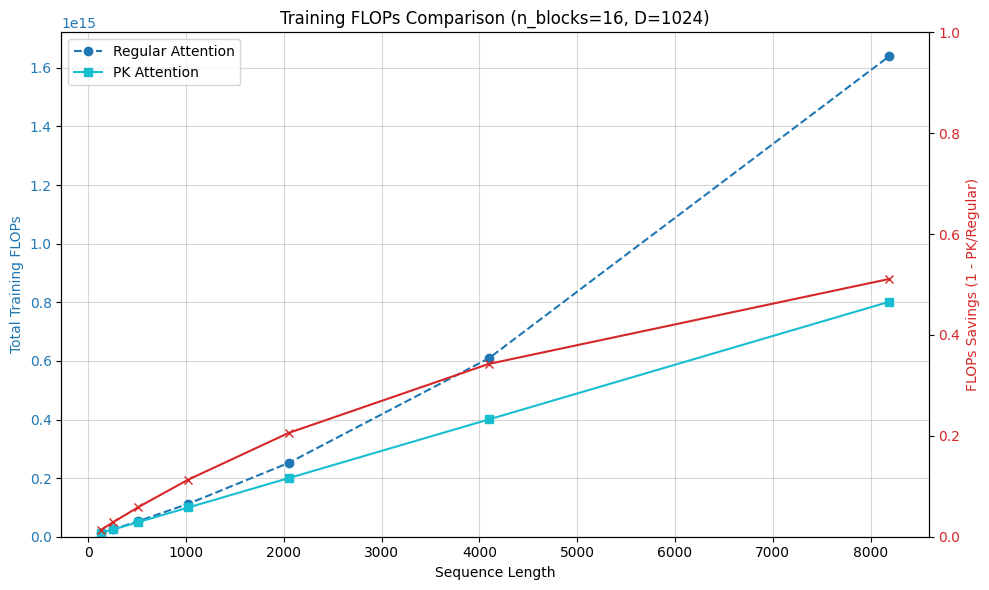

In [ ]:
import matplotlib.pyplot as plt

def plot_flops_comparison(
    n_blocks: int,
    batch_size: int,
    vocab_size: int,
    top_k: int,
    seq_lens: list,
    model_dim: int = None,
):
    if model_dim is None:
        model_dim = 64 * n_blocks

    pk_total_flops = []
    regular_total_flops = []
    ratios = []

    for s in seq_lens:
        pk_res = calculate_training_flops(
            n_blocks=n_blocks,
            model_dim=model_dim,
            batch_size=batch_size,
            seq_len=s,
            vocab_size=vocab_size,
            attention_type="pk",
            top_k=top_k,
        )
        reg_res = calculate_training_flops(
            n_blocks=n_blocks,
            model_dim=model_dim,
            batch_size=batch_size,
            seq_len=s,
            vocab_size=vocab_size,
            attention_type="regular",
            top_k=top_k,
        )

        pk_total_flops.append(pk_res[0])
        regular_total_flops.append(reg_res[0])
        ratios.append(1 - (pk_res[0] / reg_res[0]))

    fig, ax1 = plt.subplots(figsize=(10, 6))

    ax1.set_xlabel("Sequence Length")
    ax1.set_ylabel("Total Training FLOPs", color="tab:blue")
    ax1.plot(
        seq_lens,
        regular_total_flops,
        label="Regular Attention",
        marker="o",
        color="tab:blue",
        linestyle="--",
    )
    ax1.plot(
        seq_lens, pk_total_flops, label="PK Attention", marker="s", color="tab:cyan"
    )
    ax1.tick_params(axis="y", labelcolor="tab:blue")
    ax1.legend(loc="upper left")
    ax1.grid(True, which="both", ls="-", alpha=0.5)
    ax1.set_ylim(bottom=0)

    ax2 = ax1.twinx()
    ax2.set_ylabel("FLOPs Savings (1 - PK/Regular)", color="tab:red")
    ax2.plot(
        seq_lens, ratios, label="Efficiency Improvement", marker="x", color="tab:red"
    )
    ax2.tick_params(axis="y", labelcolor="tab:red")
    ax2.set_ylim(0, 1.0)

    plt.title(f"Training FLOPs Comparison (n_blocks={n_blocks}, D={model_dim})")
    fig.tight_layout()
    plt.show()

def plot_savings_by_model_size(
    n_blocks_list: list,
    batch_size: int,
    vocab_size: int,
    top_k: int,
    seq_lens: list,
):
    plt.figure(figsize=(10, 6))
    
    for n_blocks in n_blocks_list:
        model_dim = 64 * n_blocks
        savings = []
        for s in seq_lens:
            pk_res = calculate_training_flops(
                n_blocks=n_blocks,
                model_dim=model_dim,
                batch_size=batch_size,
                seq_len=s,
                vocab_size=vocab_size,
                attention_type="pk",
                top_k=top_k,
            )
            reg_res = calculate_training_flops(
                n_blocks=n_blocks,
                model_dim=model_dim,
                batch_size=batch_size,
                seq_len=s,
                vocab_size=vocab_size,
                attention_type="regular",
                top_k=top_k,
            )
            savings.append(1 - (pk_res[0] / reg_res[0]))
        
        plt.plot(seq_lens, savings, label=f"n_blocks={n_blocks}", marker="o")

    plt.xlabel("Sequence Length")
    plt.ylabel("FLOPs Savings (1 - PK/Regular)")
    plt.title("FLOPs Savings vs Sequence Length for Different Model Sizes")
    plt.legend()
    plt.grid(True, which="both", ls="-", alpha=0.5)
    plt.ylim(0, 1.0)
    plt.tight_layout()
    plt.show()

def plot_savings_by_top_k(
    n_blocks: int,
    seq_len: int,
    batch_size: int,
    vocab_size: int,
    top_k_list: list,
):
    model_dim = 64 * n_blocks
    savings = []
    
    reg_res = calculate_training_flops(
        n_blocks=n_blocks,
        model_dim=model_dim,
        batch_size=batch_size,
        seq_len=seq_len,
        vocab_size=vocab_size,
        attention_type="regular",
    )
    
    for k in top_k_list:
        pk_res = calculate_training_flops(
            n_blocks=n_blocks,
            model_dim=model_dim,
            batch_size=batch_size,
            seq_len=seq_len,
            vocab_size=vocab_size,
            attention_type="pk",
            top_k=k,
        )
        savings.append(1 - (pk_res[0] / reg_res[0]))
        
    plt.figure(figsize=(10, 6))
    plt.plot(top_k_list, savings, marker="o", linestyle="-")
    plt.xlabel("top_k")
    plt.ylabel("FLOPs Savings (1 - PK/Regular)")
    plt.title(f"FLOPs Savings vs top_k (n_blocks={n_blocks}, seq_len={seq_len})")
    plt.grid(True, which="both", ls="-", alpha=0.5)
    plt.ylim(0, 1.0)
    plt.show()

n_blocks = 16
batch_size = 64
vocab_size = 50304
top_k = 16
seq_lens = [128, 256, 512, 1024, 2048, 4096, 8192]

plot_flops_comparison(
    n_blocks=n_blocks,
    batch_size=batch_size,
    vocab_size=vocab_size,
    top_k=top_k,
    seq_lens=seq_lens,
)

# todo add red line to the legend

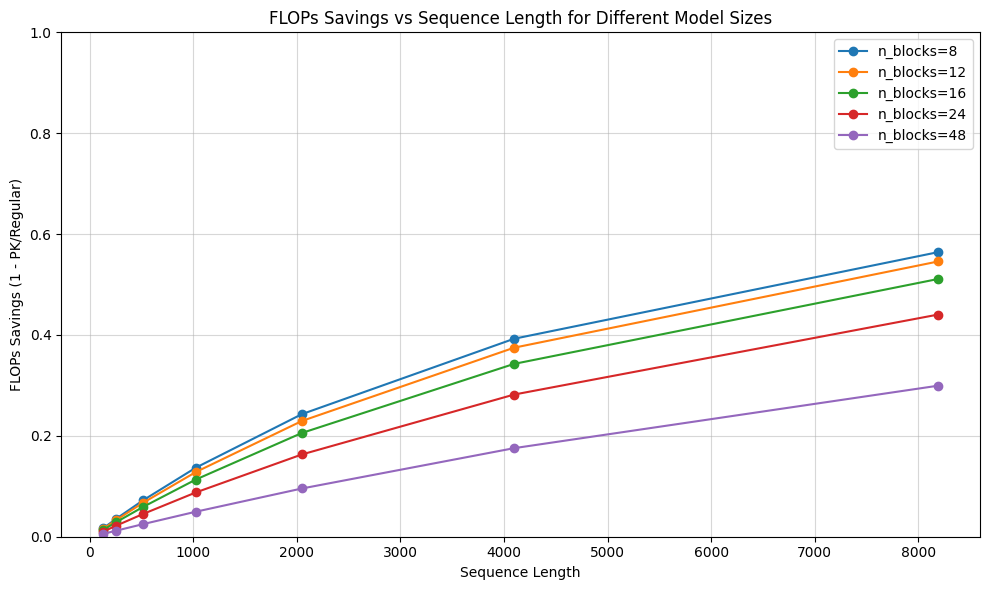

In [5]:
plot_savings_by_model_size(
    n_blocks_list=[8, 12, 16, 24, 48],
    batch_size=64,
    vocab_size=50304,
    top_k=16,
    seq_lens=[128, 256, 512, 1024, 2048, 4096, 8192],
)

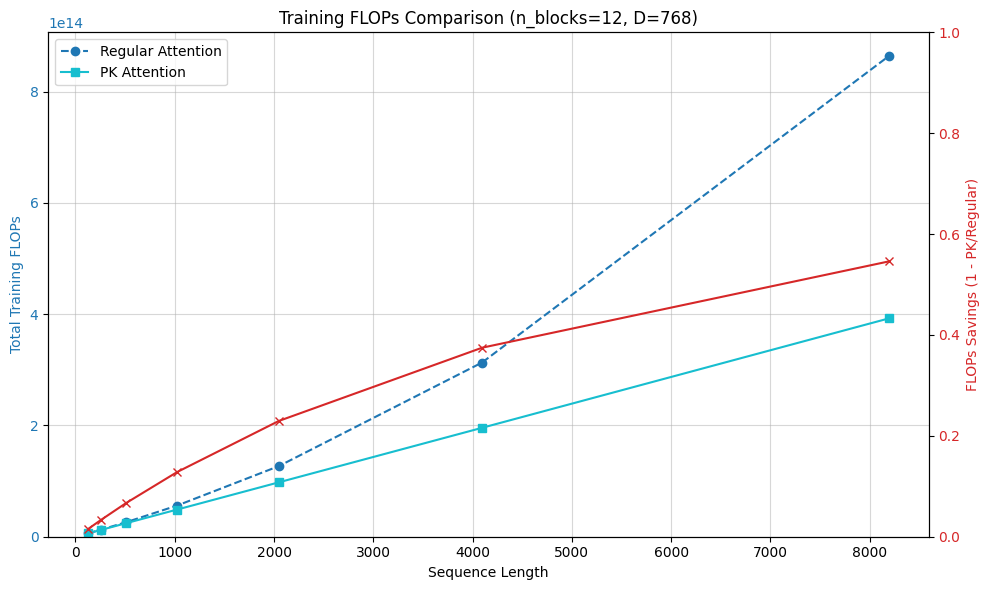

In [6]:
plot_flops_comparison(
    n_blocks=12,
    batch_size=64,
    vocab_size=50304,
    top_k=16,
    seq_lens=[128, 256, 512, 1024, 2048, 4096, 8192],
)

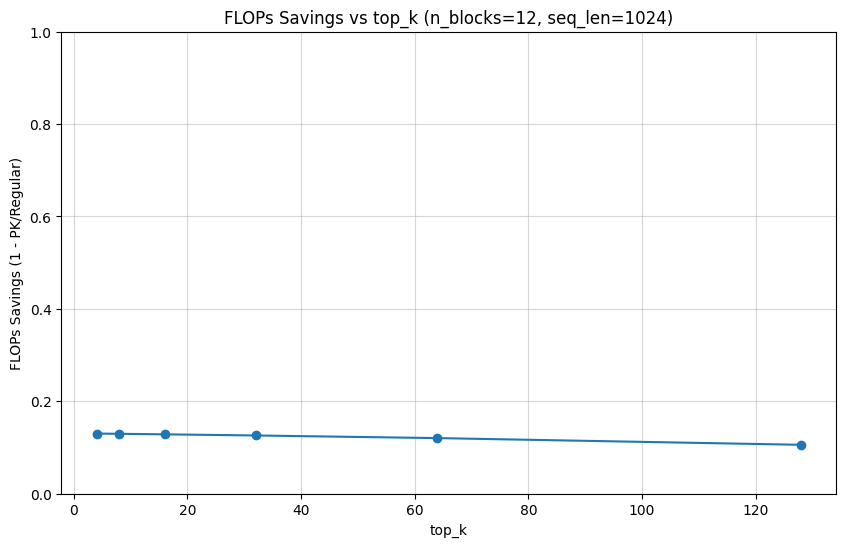

In [7]:
plot_savings_by_top_k(
    n_blocks=12,
    seq_len=1024,
    batch_size=64,
    vocab_size=50304,
    top_k_list=[4, 8, 16, 32, 64, 128],
)

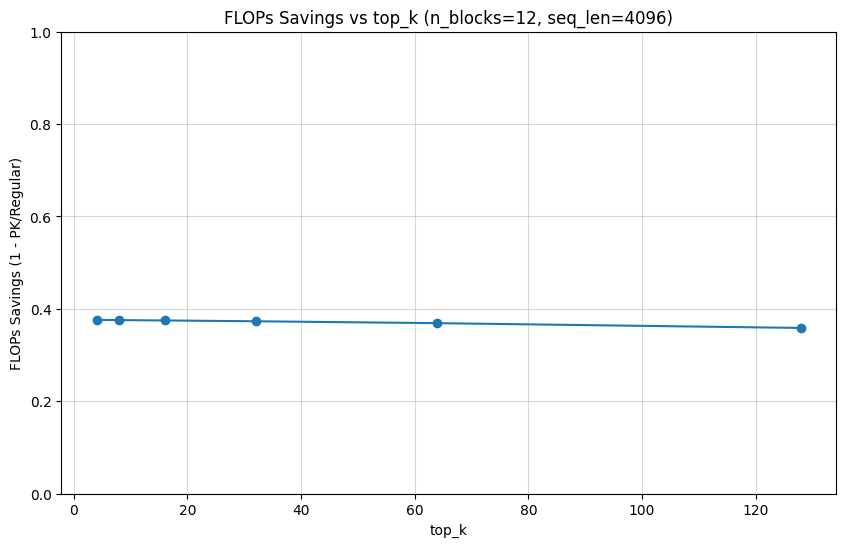

In [8]:
plot_savings_by_top_k(
    n_blocks=12,
    seq_len=4096,
    batch_size=64,
    vocab_size=50304,
    top_k_list=[4, 8, 16, 32, 64, 128],
)

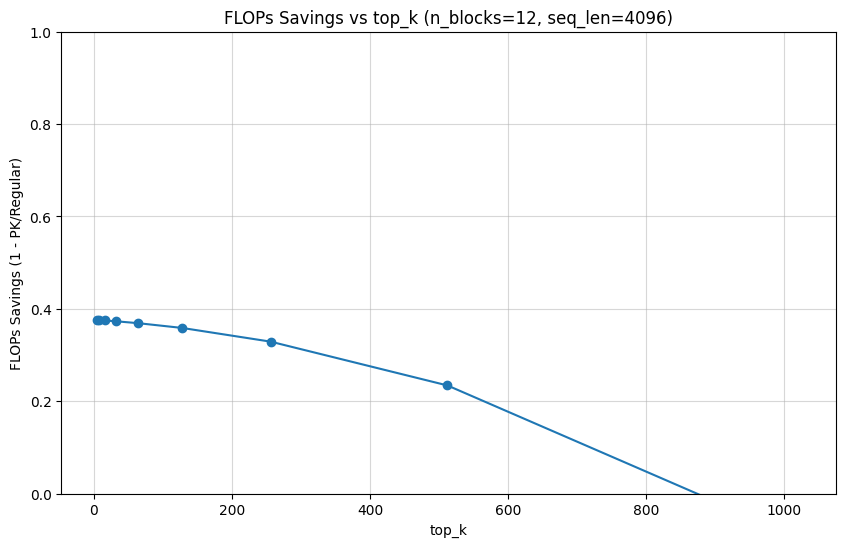

In [9]:
plot_savings_by_top_k(
    n_blocks=12,
    seq_len=4096,
    batch_size=64,
    vocab_size=50304,
    top_k_list=[4, 8, 16, 32, 64, 128, 256, 512, 1024],
)

In [10]:
n_blocks = 12
batch_size = 64
seq_len = 1024
vocab_size = 50304
n_steps = 40001

pk_steps = calculate_steps_for_equal_flops(
    n_blocks=n_blocks,
    batch_size=batch_size,
    seq_len=seq_len,
    vocab_size=vocab_size,
    n_steps=n_steps,
)

print(f"For {n_steps} steps of regular attention, PK attention should be trained for {pk_steps:.0f} steps to match FLOPs.")

For 40001 steps of regular attention, PK attention should be trained for 45885 steps to match FLOPs.


In [11]:
n_blocks = 16
batch_size = 64
seq_len = 1024
vocab_size = 50304
n_steps = 80001

pk_steps = calculate_steps_for_equal_flops(
    n_blocks=n_blocks,
    batch_size=batch_size,
    seq_len=seq_len,
    vocab_size=vocab_size,
    n_steps=n_steps,
)

print(f"For {n_steps} steps of regular attention, PK attention should be trained for {pk_steps:.0f} steps to match FLOPs.")

For 80001 steps of regular attention, PK attention should be trained for 90232 steps to match FLOPs.


In [14]:
n_blocks = 12
batch_size = 64
seq_len = 4096
vocab_size = 50304
n_steps = 10001

pk_steps = calculate_steps_for_equal_flops(
    n_blocks=n_blocks,
    batch_size=batch_size,
    seq_len=seq_len,
    vocab_size=vocab_size,
    n_steps=n_steps,
)

print(f"For {n_steps} steps of regular attention, PK attention should be trained for {pk_steps:.0f} steps to match FLOPs.")

For 10001 steps of regular attention, PK attention should be trained for 15994 steps to match FLOPs.
